In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from utils import load_data

sns.set_style("whitegrid")
sns.set_context("notebook")

plt.rcParams.update({
    'svg.fonttype': 'none',  # Export text as text not curves
    'font.size': 16, 
    "lines.linewidth": 2, 
    "axes.labelsize": 18,
    "axes.titlesize": 22
})

In [2]:
df, top_k, source = load_data(f"results/mcl1_mmgbsa_init_sample_effect.sqlite", k_ratio=0.01)
K = len(top_k)

In [3]:
df[df["Iteration"] == 0].groupby(["Embedding Model", "sampler", "init_sampler", "init_batch_size"])["is_top_k"].any()

Embedding Model     sampler               init_sampler  init_batch_size
ChemBERTa-2         expected-improvement  closest       1                  False
                                                        5                  False
                                                        10                 False
                                                        20                 False
                                                        50                 False
                                                        100                False
                                                        600                False
                                                        1200                True
                                                        1800                True
                                          random        1                  False
                                                        5                  False
                                     

In [4]:
top_k_retrieval = df[df["Iteration"] > 0].groupby(["experiment_id", "Embedding Model", "sampler", "init_sampler", "init_batch_size"])["is_top_k"].sum()
top_k_retrieval = top_k_retrieval.reset_index()
top_k_retrieval.groupby(["Embedding Model", "sampler", "init_sampler", "init_batch_size"])["is_top_k"].mean() / K

Embedding Model     sampler               init_sampler  init_batch_size
ChemBERTa-2         expected-improvement  closest       1                  0.193277
                                                        5                  0.094118
                                                        10                 0.087395
                                                        20                 0.149580
                                                        50                 0.188235
                                                        100                0.196639
                                                        600                0.294118
                                                        1200               0.191597
                                                        1800               0.176471
                                          random        1                  0.193277
                                                        5                  0.162017
    

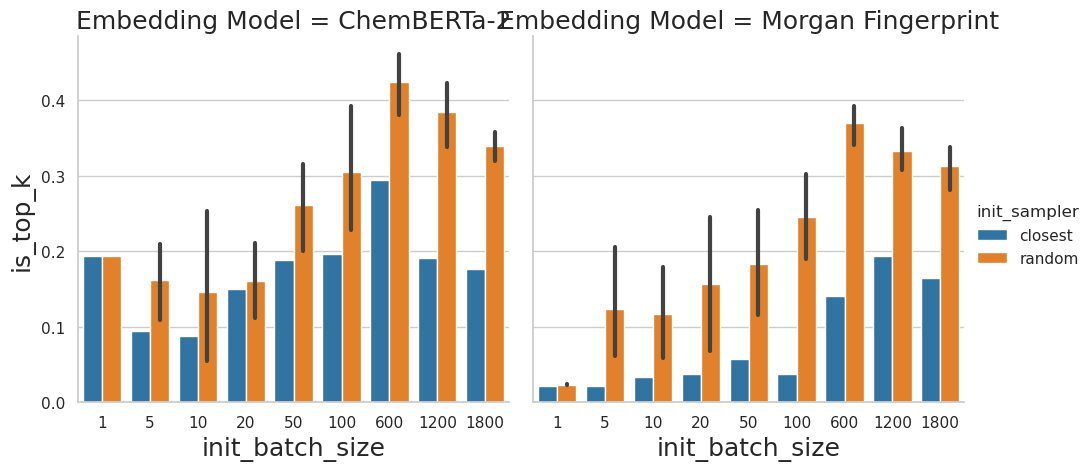

In [8]:
sns.catplot(
    top_k_retrieval,
    x="init_batch_size",
    y=top_k_retrieval["is_top_k"] / K,
    col="Embedding Model",
    col_order=["ChemBERTa-2", "Morgan Fingerprint"],
    hue="init_sampler",
    kind="bar",
)

In [10]:
df["Molecules screened"] = df["init_batch_size"] + df["Iteration"] * df["batch_size"]
stats = (df
        # First sum per experiment
        .groupby(["Embedding Model", 'init_batch_size', 'init_sampler', 'Molecules screened', 'experiment_id'])['is_top_k_cum']
        .max()
        # Then get stats across experiments
        .reset_index()
    )
stats


,Embedding Model,init_batch_size,init_sampler,Molecules screened,experiment_id,is_top_k_cum
0,ChemBERTa-2,1,closest,1,98,0
1,ChemBERTa-2,1,closest,3600,98,115
2,ChemBERTa-2,1,random,1,100,0
3,ChemBERTa-2,1,random,1,102,0
4,ChemBERTa-2,1,random,1,103,0
...,...,...,...,...,...,...
211,Morgan Fingerprint,1800,random,3600,4,228
212,Morgan Fingerprint,1800,random,3600,6,170
213,Morgan Fingerprint,1800,random,3600,8,197
214,Morgan Fingerprint,1800,random,3600,9,207


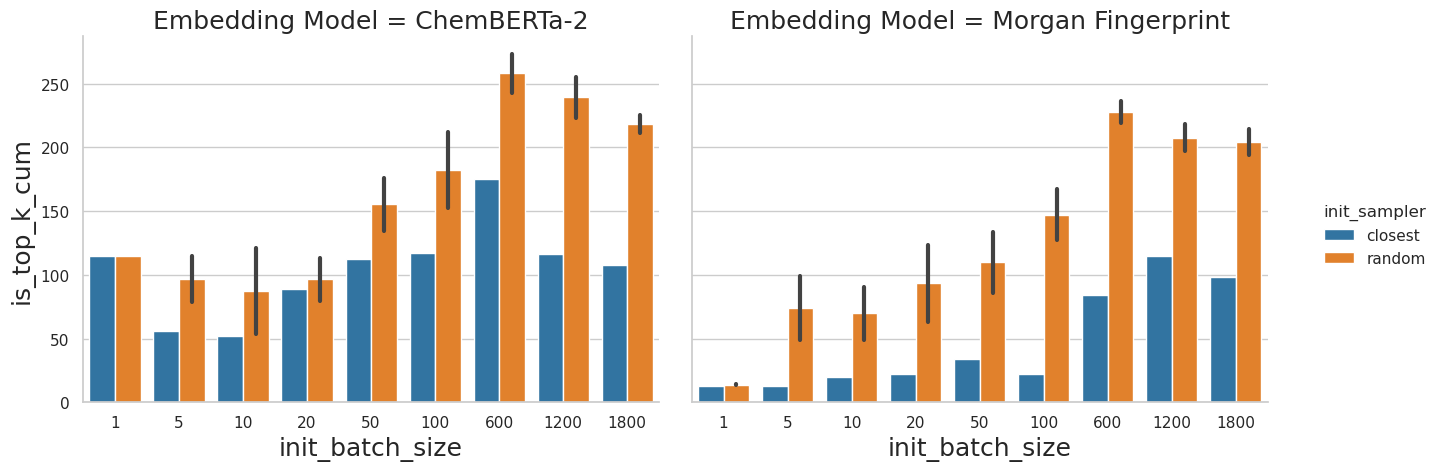

In [24]:
g = sns.catplot(
    stats[stats["Molecules screened"] == 3600],
    x="init_batch_size",
    y = "is_top_k_cum",
    errorbar="se",
    # errorbar=("ci", 100),
    hue="init_sampler",
    kind="bar",
    col="Embedding Model",
    col_order=["ChemBERTa-2", "Morgan Fingerprint"],
)
g.figure.set_size_inches(15, 5)

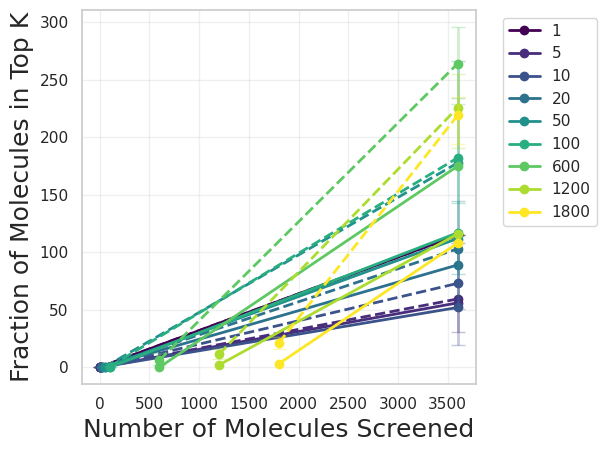

In [141]:
from matplotlib.colors import Normalize

batch_sizes = stats['init_batch_size'].unique()

norm = Normalize(vmin=min(batch_sizes), vmax=max(batch_sizes))
colors = plt.cm.viridis(np.linspace(0, 1, len(batch_sizes)))
for batch_size, color in zip(batch_sizes, colors):
    batch_data = stats[stats['init_batch_size'] == batch_size]
    
    # Plot closest sampler (solid line)
    closest = batch_data[batch_data['init_sampler'] == 'closest']
    plt.plot(closest['Molecules screened'], closest['mean'], 
             label=str(batch_size), linestyle='-', color=color, marker="o")
    
    # Plot random sampler (dashed line with error bars)
    random = batch_data[batch_data['init_sampler'] == 'random']
    plt.plot(random['Molecules screened'], random['mean'], linestyle='--', color=color, marker="o")
    plt.errorbar(random['Molecules screened'], random['mean'],
                yerr=[random['mean'] - random['min'], random['max'] - random['mean']],
                fmt='none', alpha=0.3, capsize=5, color=color)

plt.xlabel('Number of Molecules Screened')
plt.ylabel('Fraction of Molecules in Top K')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

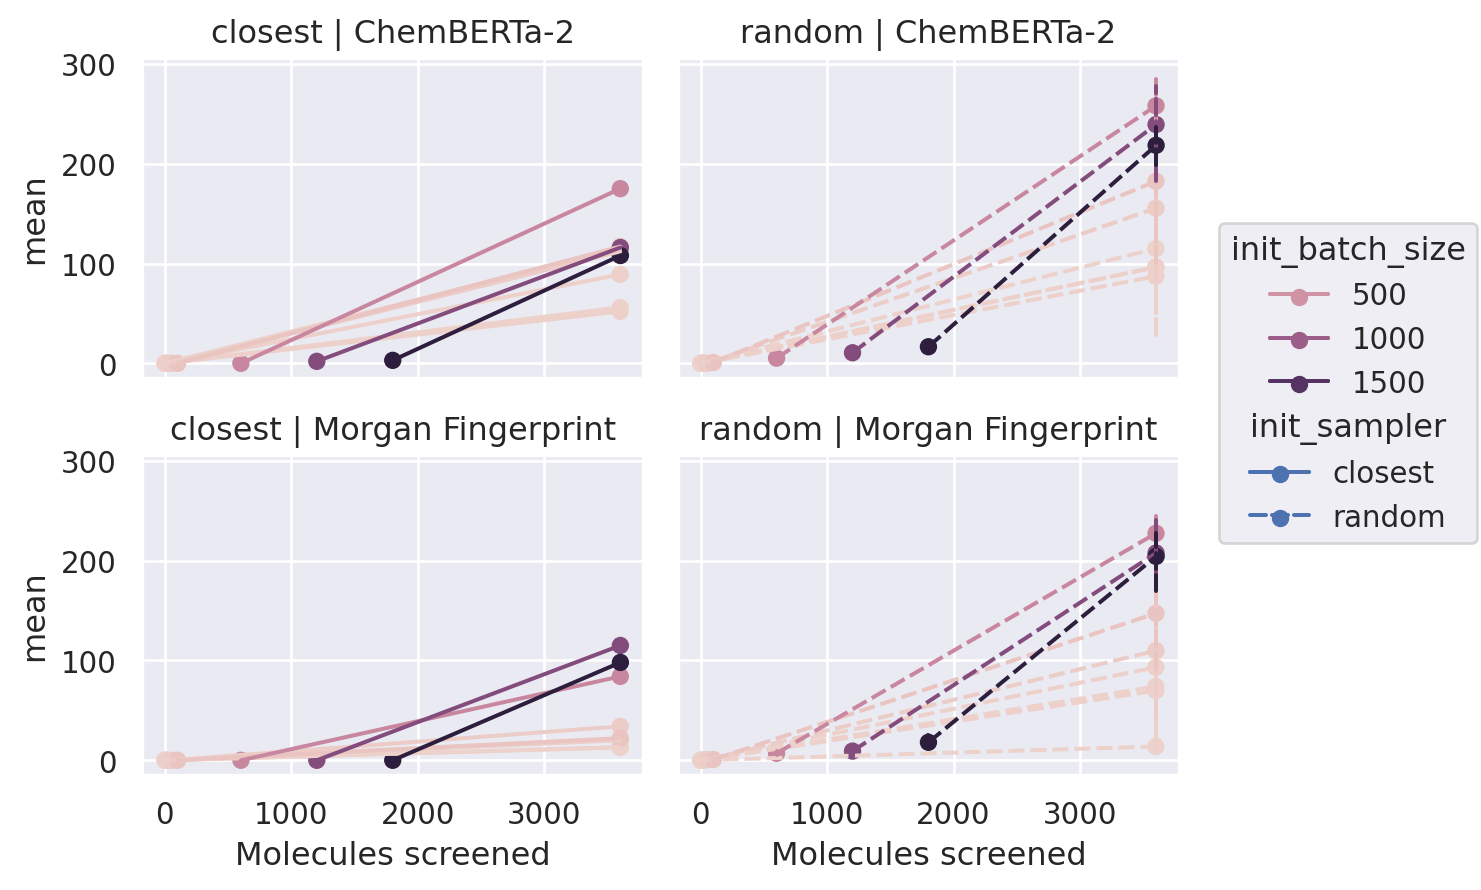

In [15]:
import seaborn.objects as so

agg_stats = stats.groupby(["Embedding Model", 'init_batch_size', 'init_sampler', 'Molecules screened'])["is_top_k_cum"].agg(['mean', 'min', 'max'])

(
    so.Plot(agg_stats, x="Molecules screened", y="mean", color="init_batch_size", linestyle="init_sampler", ymin="min", ymax="max")
    .add(so.Line(), so.Dodge())
    .add(so.Range(), so.Dodge())
    .add(so.Dot(), so.Dodge())
    .facet(col="init_sampler", row="Embedding Model")
)